# Module 3 — Session 3: Practical Exercises


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Exercise 1.1 — Handling Missing Age Values

In [2]:
age_mean = df['Age'].mean()
age_median = df['Age'].median()

age_mean, age_median


(np.float64(29.69911764705882), np.float64(28.0))

The mean is affected by outliers (very old passengers), so it is slightly higher.
The median is more robust and represents the typical age better.
Therefore, we use the median to fill missing Age values.


In [3]:
df['Age'] = df['Age'].fillna(age_median)


### Exercise 1.2 — Filling Missing Embarked Values


In [4]:
embarked_mode = df['Embarked'].mode()[0]
embarked_mode


'S'

In [5]:
df['Embarked'] = df['Embarked'].fillna(embarked_mode)


### Exercise 1.3 — Dropping the Cabin Column

In [6]:
cabin_missing_percentage = df['Cabin'].isna().mean() * 100
cabin_missing_percentage


np.float64(77.10437710437711)

In [7]:
df = df.drop(columns=['Cabin'])


### Exercise 1.4 — Verification

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


### Exercise 2.1 — Detecting Outliers in Fare

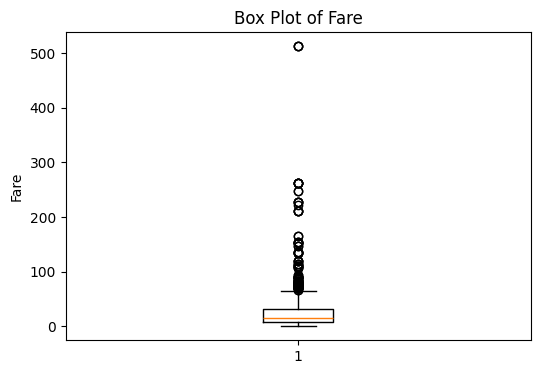

In [9]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Fare'])
plt.title("Box Plot of Fare")
plt.ylabel("Fare")
plt.show()


### Exercise 2.2 — Calculating IQR and Outlier Boundaries


In [10]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

Q1, Q3, IQR, upper_bound


(np.float64(7.9104),
 np.float64(31.0),
 np.float64(23.0896),
 np.float64(65.6344))

### Exercise 2.3 — Capping Outliers

In [11]:
df.loc[df['Fare'] > upper_bound, 'Fare'] = upper_bound


### Exercise 2.4 — Visualizing Fare After Capping

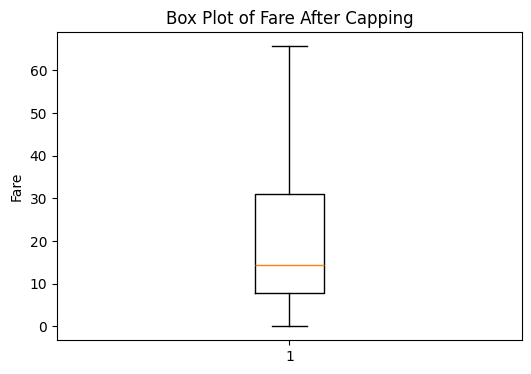

In [12]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Fare'])
plt.title("Box Plot of Fare After Capping")
plt.ylabel("Fare")
plt.show()


## Exercise 3 — Cleaning Categorical Data

**Note:** The Titanic dataset does *not* contain a `Country` column.
This exercise is purely conceptual. Below is the correct approach you would use if such a column existed.

### 1. Inspect the Data
Before cleaning, inspect the categories:
```python
df['Country'].value_counts()
```


### 2. Normalize Formatting
Convert all values to lowercase and remove extra spaces:
```python
df['Country'] = df['Country'].str.lower().str.strip()
```

### 3. Create a Mapping Dictionary
Unify inconsistent variations referring to the same country:
```python
mapping = {
    'usa': 'United States',
    'u.s.a': 'United States',
    'united states': 'United States',
    'america': 'United States'
}
df['Country'] = df['Country'].replace(mapping)
```

### 4. Verify Results
Check the cleaned categories:
```python
df['Country'].value_counts()
```
### Final Clean Categories:
- United States
- Canada
- Germany